# SQL in Python - Connecting to and retrieving data from PostgreSQL

Previously, you have learned how to connect to a SQL database by using a SQL client such as DBeaver. Apart from connecting to databases, DBeaver also allows you to run SQL queries against the database, create new tables and populate them with data as well as retrieving the data.

Python also allows executing SQL queries and getting the result into a Python object, for example a Pandas data frame. Instead of exporting a .csv file from DBeaver you can directly get the data you need into Python and continue your work. In addition we can reduce the steps by connecting to the database from Python directly, eliminating the need for a separate SQL client.

After you have the data in Python in the required shape you can export the data into a .csv file. This file is for your own reference, please avoid sending .csv files around - database is the point of reference when it comes to data. 

Having a copy of a .csv file (or another format) can speed up your analysis work. Imagine that the query takes 25 minutes to run. If you made some mistakes in your Python code you might need to go back to the original dataset. Instead of having to rerun the SQL query and having to wait you can read in the .csv file you have previously saved on your hard disk into Python and continue with your analysis work. 

**In this notebook you will see 2 ways to connect to SQL-Databases and export the data to a CSV file**


## Creating a connection to a PostgreSQL database with Python

There are 2 python packages that are the "go-to" when it comes to connecting to SQL-Databases: `psycopg2` and `sqlalchemy` 

### Connecting via psycopg2

In [1]:
import pandas as pd
import psycopg2



In order to create a connection to our PostgreSQL database we need the following information:

- host = the address of the machine the database is hosted on
- port = the virtual gate number through which communication will be allowed
- database = the name of the database
- user = the name of the user
- password = the password of the user

Because we don't want that the database information is published on github we put it into a `.env` file which is added into the `.gitignore`. 
In these kind of files you can store information that is not supposed to be published.
With the `dotenv` package you can read the `.env` files and get the variables.
(We will share the file with you on Slack!)


In [2]:
import os
from dotenv import load_dotenv

# READ database user password host and port from .env
load_dotenv()

DATABASE = os.getenv('DATABASE')
USER_DB = os.getenv('USER_DB')
PASSWORD = os.getenv('PASSWORD')
HOST = os.getenv('HOST')
PORT = os.getenv('PORT')

The function from the psycopg2 package to create a connection is called `connect()`.
`connect()` expects the parameters listed above as input in order to connect to the database.

In [3]:
# Create connection object conn
conn = psycopg2.connect(
    database=DATABASE,
    user=USER_DB,
    password=PASSWORD,
    host=HOST,
    port=PORT
)

### Retrieving data from the database with psycopg2

Before we can use our connection to get data, we have to create a cursor. A cursor allows Python code to execute PostgreSQL commmands in a database session.
A cursor has to be created with the `cursor()` method of our connection object conn.

In [4]:
cur = conn.cursor()

Now we can run SQL-Queries with `cur.execute('QUERY')` and then run `cur.fetchall()` to get the data:

In [5]:
cur.execute('SELECT * FROM eda.king_county_house_sales LIMIT 10')
cur.fetchall()

[(datetime.date(2014, 10, 13), 221900.0, 7129300520, 1),
 (datetime.date(2014, 12, 9), 538000.0, 6414100192, 2),
 (datetime.date(2015, 2, 25), 180000.0, 5631500400, 3),
 (datetime.date(2014, 12, 9), 604000.0, 2487200875, 4),
 (datetime.date(2015, 2, 18), 510000.0, 1954400510, 5),
 (datetime.date(2014, 5, 12), 1230000.0, 7237550310, 6),
 (datetime.date(2014, 6, 27), 257500.0, 1321400060, 7),
 (datetime.date(2015, 1, 15), 291850.0, 2008000270, 8),
 (datetime.date(2015, 4, 15), 229500.0, 2414600126, 9),
 (datetime.date(2015, 3, 12), 323000.0, 3793500160, 10)]

With `conn.close()` you can close the connection again.

In [8]:
#close the connection
conn.close()

But we want to work with the data. The easiest way is to import the data into pandas dataframes. We can use `pd.read_sql_query` or `pd.read_sql_table` or for convenience `pd.read_sql`.

This function is a convenience wrapper around read_sql_table and read_sql_query (for backward compatibility). It will delegate to the specific function depending on the provided input. A SQL query will be routed to read_sql_query , while a database table name will be routed to read_sql_table . Note that the delegated function might have more specific notes about their functionality not listed here.

In [9]:
# Open connection again because we closed it
conn = psycopg2.connect(
    database=DATABASE,
    user=USER_DB,
    password=PASSWORD,
    host=HOST,
    port=PORT
)

In [10]:
# import the data into a pandas dataframe
query_string = "SELECT * FROM eda.king_county_house_sales LIMIT 10"
df_psycopg = pd.read_sql(query_string, conn)

C:\Users\Mahesh\AppData\Local\Temp\ipykernel_22376\1176423828.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_psycopg = pd.read_sql(query_string, conn)


In [11]:
#close the connection
conn.close()

In [12]:
df_psycopg.head()

,date,price,house_id,id
0,2014-10-13,221900.0,7129300520,1
1,2014-12-09,538000.0,6414100192,2
2,2015-02-25,180000.0,5631500400,3
3,2014-12-09,604000.0,2487200875,4
4,2015-02-18,510000.0,1954400510,5


In [21]:
#export the data to a csv-file
query_string = "SELECT kchd.*, kchs.date, kchs.price \
	FROM king_county_house_details kchd \
		LEFT JOIN king_county_house_sales kchs \
			ON 	kchd.id = kchs.house_id;"
df_psycopg.to_csv('data/eda.csv',index=False)

### Connecting and retrieving data via SQLAlchemy

`sqlalchemy` works similarly. Here you have to create an engine with the database sting (a link that includes every information we entered in the conn object)

In [22]:
from sqlalchemy import create_engine

# READ database user password host and port from .env
load_dotenv()

DATABASE = os.getenv('DATABASE')
USER_DB = os.getenv('USER_DB')
PASSWORD = os.getenv('PASSWORD')
HOST = os.getenv('HOST')
PORT = os.getenv('PORT')

#DB_STRING = os.getenv('DB_STRING')

DB_STRING = f"postgresql://{USER_DB}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
db = create_engine(DB_STRING)



And then you can import that engine with a query into a pandas dataframe.

In [ ]:
#import the data to a pandas dataframe
query_string = "SELECT * FROM eda.king_county_house_sales"
df_sqlalchemy = pd.read_sql(query_string, db)

In [24]:
df_sqlalchemy.head()

,date,price,house_id,id
0,2014-10-13,221900.0,7129300520,1
1,2014-12-09,538000.0,6414100192,2
2,2015-02-25,180000.0,5631500400,3
3,2014-12-09,604000.0,2487200875,4
4,2015-02-18,510000.0,1954400510,5


Because we don't want to run the queries over and over again we can export the data into a .csv file in order to use it in other notebooks as well. 

In [28]:
#export the data to a csv-file
df_sqlalchemy.to_csv('eda.csv',index=False)

In [20]:
#import the data from a csv-file
df_import = pd.read_csv('data/eda.csv')

In [30]:
query_string = "SET SCHEMA 'eda'; \
    SELECT kchd.*, kchs.date, kchs.price \
	FROM king_county_house_details kchd \
		LEFT JOIN king_county_house_sales kchs \
			ON 	kchd.id = kchs.house_id;"
df_sqlalchemy = pd.read_sql(query_string, db)

#export the housing data to a csv-file
df_sqlalchemy.to_csv('data/eda_housing.csv',index=False)

In [35]:
df_sqlalchemy.head(10)
df = df_sqlalchemy.copy()
df.columns
df[df["price"]>20000]

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,3.0,2.50,1530.0,1131.0,3.0,0.0,0.0,3,8,...,0.0,2009,0.0,98103,47.6993,-122.346,1530.0,1509.0,2014-05-21,360000.0
21593,6600060120,4.0,2.50,2310.0,5813.0,2.0,0.0,0.0,3,8,...,0.0,2014,0.0,98146,47.5107,-122.362,1830.0,7200.0,2015-02-23,400000.0
21594,1523300141,2.0,0.75,1020.0,1350.0,2.0,0.0,0.0,3,7,...,0.0,2009,0.0,98144,47.5944,-122.299,1020.0,2007.0,2014-06-23,402101.0
21595,291310100,3.0,2.50,1600.0,2388.0,2.0,NaN,0.0,3,8,...,0.0,2004,0.0,98027,47.5345,-122.069,1410.0,1287.0,2015-01-16,400000.0


In [60]:
df.columns
numeric_df = df.select_dtypes(include=['number'])
numeric_df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'price'],
      dtype='object')

In [ ]:
# Filter for Jacob Phillip's preferences
# Assumptions:
# - 'sqft_lot' > 15000 is considered big (enough for tennis court & pool)
# - 'bathrooms' >= 4 for 4+ bathrooms
# - 'waterfront' == 0 for no waterfront
# - 'sqft_living' < 2000 for "smaller house nearby" (adjust as needed)
# - 'golf' and 'historic' columns/tags are not present, so these are not filtered

filtered = df[
    ((df['bathrooms'] >= 4) | (df['sqft_living'] < 2000)) &
    (df['sqft_lot'] > 15000) &
    (df['waterfront'] == 0)
]
print(f"Total results meeting the client req: {filtered.values()}")
# Show the top results
filtered.head(10)


Total results meeting the client req: id               969
bedrooms         969
bathrooms        969
sqft_living      969
sqft_lot         969
floors           969
waterfront       969
view             966
condition        969
grade            969
sqft_above       969
sqft_basement    953
yr_built         969
yr_renovated     823
zipcode          969
lat              969
long             969
sqft_living15    969
sqft_lot15       969
date             969
price            969
dtype: int64


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
5,7237550310,4.0,4.50,5420.0,101930.0,1.0,0.0,0.0,3,11,...,1530.0,2001,0.0,98053,47.6561,-122.005,4760.0,101930.0,2014-05-12,1230000.0
12,114101516,3.0,1.00,1430.0,19901.0,1.5,0.0,0.0,4,7,...,0.0,1927,NaN,98028,47.7558,-122.229,1780.0,12697.0,2014-05-28,310000.0
36,9435300030,4.0,1.00,1660.0,34848.0,1.0,0.0,0.0,1,5,...,730.0,1933,0.0,98052,47.6621,-122.132,2160.0,11467.0,2014-05-28,550000.0
74,3444100400,3.0,1.75,1790.0,50529.0,1.0,0.0,0.0,5,7,...,700.0,1965,0.0,98042,47.3511,-122.073,1940.0,50529.0,2015-03-16,349000.0
75,3276920270,4.0,4.00,3430.0,35102.0,2.0,0.0,0.0,4,10,...,1040.0,1986,0.0,98075,47.5822,-121.987,3240.0,35020.0,2014-11-05,832500.0
96,3422049190,3.0,1.75,1960.0,15681.0,1.0,0.0,0.0,3,7,...,0.0,1967,0.0,98032,47.3576,-122.277,1750.0,15616.0,2015-03-30,247500.0
98,722079104,3.0,1.75,1810.0,41800.0,1.0,0.0,0.0,5,7,...,600.0,1980,0.0,98038,47.4109,-121.958,1650.0,135036.0,2014-07-11,314000.0
104,6197800045,3.0,1.00,1210.0,33919.0,1.0,0.0,0.0,3,7,...,0.0,1954,0.0,98058,47.4375,-122.184,1640.0,14910.0,2014-09-24,290000.0
135,921049315,3.0,1.75,1320.0,17390.0,1.0,0.0,0.0,4,7,...,0.0,1956,NaN,98003,47.3257,-122.296,1550.0,19265.0,2014-08-13,199000.0
170,4330600435,3.0,1.75,1560.0,21000.0,1.0,0.0,0.0,3,7,...,0.0,1954,0.0,98166,47.4776,-122.337,1070.0,7920.0,2015-03-16,284000.0


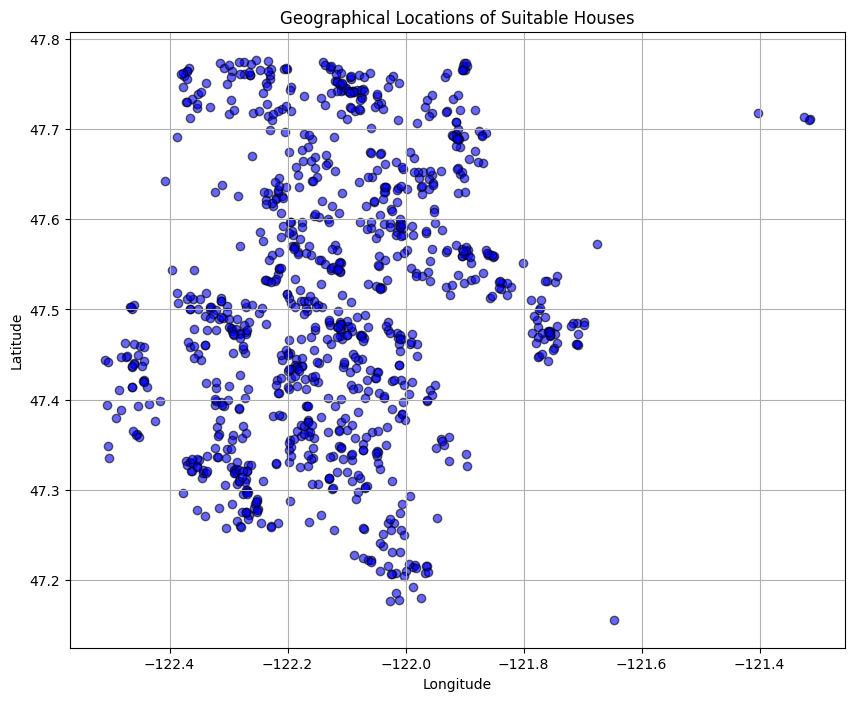

In [67]:
# Plot the locations of suitable houses
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(filtered['long'], filtered['lat'], c='blue', alpha=0.6, edgecolor='k')
plt.title('Geographical Locations of Suitable Houses')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

KeyboardInterrupt: 

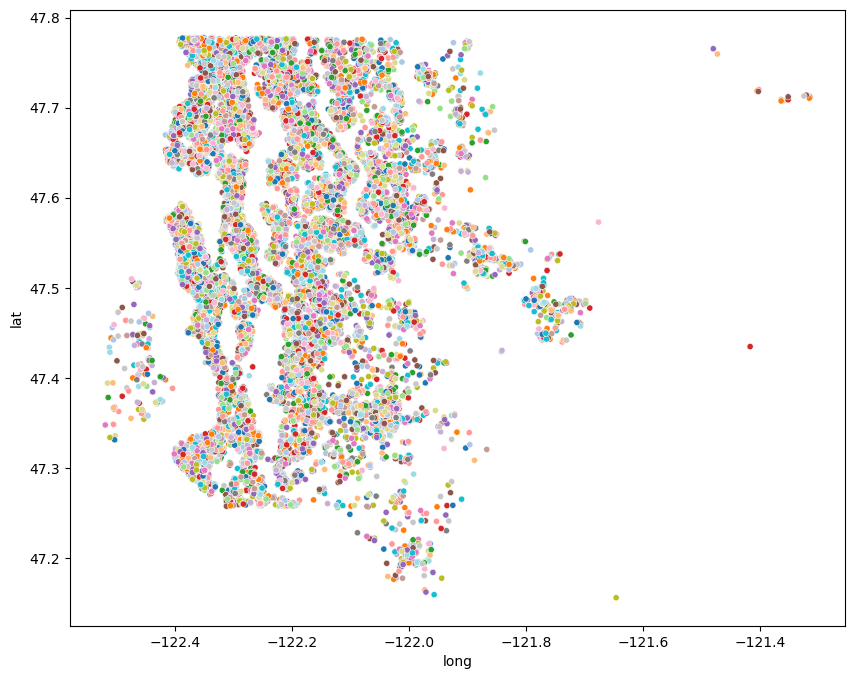

In [ ]:
# Plot houses by geolocation, colored by zipcode
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df, x='long', y='lat', hue='price', palette='tab20', legend='full', s=20)
# plt.title('Houses by Zip Code and Geolocation')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='price')
# plt.tight_layout()
# # plt.show();

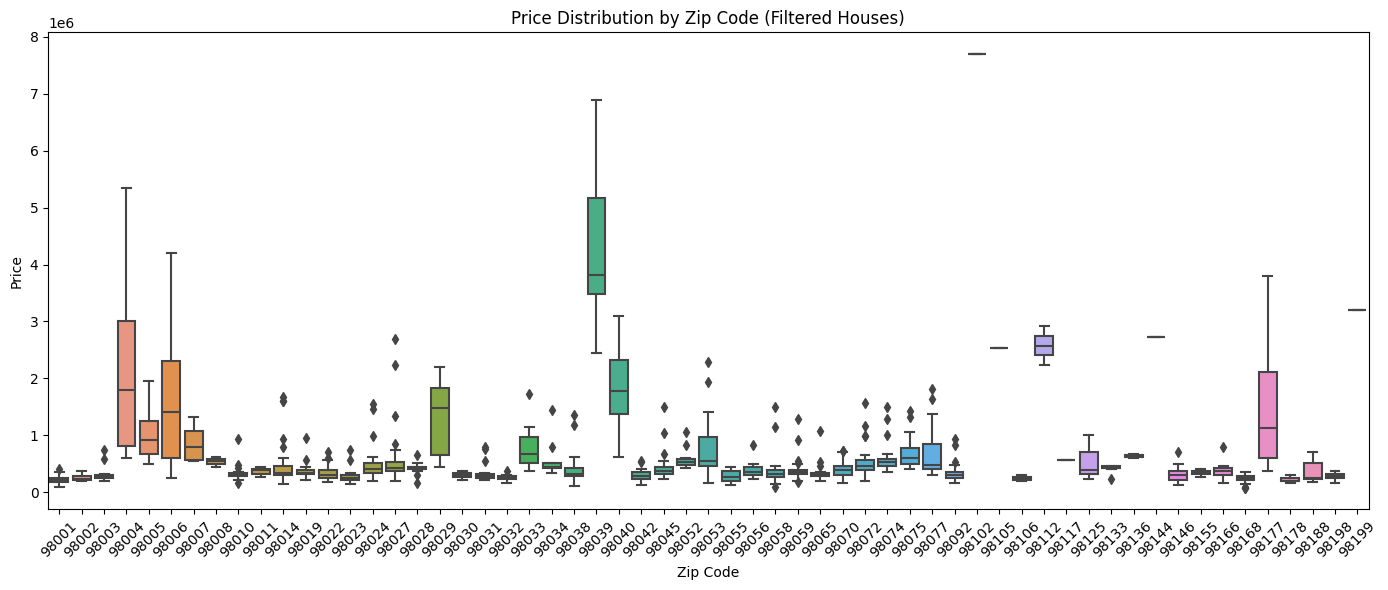

Zip codes with most suitable houses:
zipcode
98001    44
98045    40
98070    40
98022    39
98042    39
Name: count, dtype: int64

Zip codes with lowest median price:
zipcode
98178    195000.0
98001    217500.0
98002    237300.0
98106    240000.0
98032    244750.0
Name: price, dtype: float64


In [ ]:
# Plot price vs zip code for filtered houses
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.boxplot(x='zipcode', y='price', data=filtered)
plt.title('Price Distribution by Zip Code (Filtered Houses)')
plt.xlabel('Zip Code')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Find the zip code with the most suitable houses (e.g., most listings or lowest median price)
zip_counts = filtered['zipcode'].value_counts().sort_values(ascending=False)
zip_median_price = filtered.groupby('zipcode')['price'].median().sort_values()

print('Zip codes with most suitable houses:')
print(zip_counts.head())
print('\nZip codes with lowest median price:')
print(zip_median_price.head())